# CartPole-v1: REINFORCE vs. REINFORCE with Baseline

This notebook implements **REINFORCE** and **REINFORCE with a learned state-value baseline** for Gymnasium's `CartPole-v1`.


The final section trains both algorithms over multiple random seeds, plots mean return with confidence intervals, plots rolling variance, and saves trained model checkpoints with `torch.save()`.


## 1. Setup

Install dependencies first if needed:

```bash
pip install gymnasium[classic-control] torch matplotlib numpy pandas
```


In [21]:
# TAG: setup-imports
%matplotlib inline

import os
import random
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple

import gymnasium as gym
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

print("NumPy version:      ", np.__version__)
print("PyTorch version:    ", torch.__version__)
print("Gymnasium version:  ", gym.__version__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


NumPy version:       2.4.2
PyTorch version:     2.11.0
Gymnasium version:   1.2.3
Using device: cpu


In [22]:
# TAG: reproducibility

def set_global_seed(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_env(seed: int):
    """Create a seeded CartPole-v1 environment."""
    env = gym.make("CartPole-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env


## 2. Neural Networks

CartPole-v1 has a continuous `Box` observation space with 4 values:

1. cart position,
2. cart velocity,
3. pole angle,
4. pole angular velocity.

It has a discrete action space with 2 actions:

- `0`: push cart left,
- `1`: push cart right.

The policy network maps the 4-dimensional state into 2 action logits. We then apply `F.softmax()` and sample from `Categorical`.


In [23]:
# TAG: neural-networks

class PolicyNetwork(nn.Module):
    """Policy network: state -> action logits."""

    def __init__(self, obs_dim: int, action_dim: int, hidden_sizes: Tuple[int, ...] = (128, 128)):
        super().__init__()
        layers = []
        input_dim = obs_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, action_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def get_action_and_log_prob(self, obs_np: np.ndarray) -> Tuple[int, torch.Tensor]:
        """Convert NumPy observation to tensor, sample action, and return log probability."""
        obs = torch.as_tensor(obs_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits = self.forward(obs)
        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs=probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return int(action.item()), log_prob.squeeze(0)


class ValueNetwork(nn.Module):
    """Baseline network: state -> scalar V(s)."""

    def __init__(self, obs_dim: int, hidden_sizes: Tuple[int, ...] = (128, 128)):
        super().__init__()
        layers = []
        input_dim = obs_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


## 3. Episode Collection and Return Calculation

REINFORCE is a Monte Carlo policy-gradient method. It collects a **complete episode**, then computes the discounted return:

\[
G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots
\]

For CartPole, rewards are usually `+1` per time step until termination, so higher return means the pole stayed balanced longer.


In [24]:
# TAG: returns-and-rollout

def compute_returns(rewards: List[float], gamma: float) -> torch.Tensor:
    """Compute discounted returns G_t for one complete episode."""
    returns = []
    G = 0.0

    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.append(G)

    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32, device=DEVICE)


def collect_episode(env, policy: PolicyNetwork, gamma: float) -> Dict[str, object]:
    """Collect a complete episode using the current policy."""
    obs, info = env.reset()

    states = []
    actions = []
    rewards = []
    log_probs = []

    terminated = False
    truncated = False

    while not (terminated or truncated):
        action, log_prob = policy.get_action_and_log_prob(obs)

        next_obs, reward, terminated, truncated, info = env.step(action)

        states.append(obs.copy())
        actions.append(action)
        rewards.append(float(reward))
        log_probs.append(log_prob)

        obs = next_obs

    returns = compute_returns(rewards, gamma)

    return {
        "states": np.array(states, dtype=np.float32),
        "actions": np.array(actions, dtype=np.int64),
        "rewards": rewards,
        "log_probs": log_probs,
        "returns": returns,
        "episode_return": float(sum(rewards)),
        "episode_length": len(rewards),
    }


## 4. REINFORCE without Baseline

The policy loss is:

\[
L_\pi = -\sum_t \log \pi_	heta(a_t|s_t)G_t
\]

The negative sign appears because PyTorch optimizers minimize loss, while policy gradient is normally written as gradient ascent.


In [25]:
# TAG: train-reinforce

@dataclass
class TrainConfig:
    env_id: str = "CartPole-v1"
    num_episodes: int = 600
    gamma: float = 0.99
    policy_lr: float = 1e-3
    value_lr: float = 1e-3
    hidden_sizes: Tuple[int, ...] = (128, 128)
    normalize_returns: bool = True
    checkpoint_dir: str = "checkpoints_cartpole_reinforce"


def train_reinforce(seed: int, config: TrainConfig) -> Tuple[pd.DataFrame, PolicyNetwork]:
    """Train vanilla REINFORCE without a baseline."""
    set_global_seed(seed)
    env = make_env(seed)

    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy = PolicyNetwork(obs_dim, action_dim, config.hidden_sizes).to(DEVICE)
    optimizer = optim.Adam(policy.parameters(), lr=config.policy_lr)

    history = []

    for episode in range(1, config.num_episodes + 1):
        episode_data = collect_episode(env, policy, config.gamma)

        log_probs = torch.stack(episode_data["log_probs"])
        returns = episode_data["returns"]

        # Optional return normalization reduces gradient scale instability.
        # This is not a learned baseline; it only rescales the Monte Carlo targets.
        if config.normalize_returns and len(returns) > 1:
            returns_for_loss = (returns - returns.mean()) / (returns.std(unbiased=False) + 1e-8)
        else:
            returns_for_loss = returns

        policy_loss = -(log_probs * returns_for_loss).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        history.append({
            "algorithm": "REINFORCE",
            "seed": seed,
            "episode": episode,
            "return": episode_data["episode_return"],
            "length": episode_data["episode_length"],
            "policy_loss": float(policy_loss.detach().cpu().item()),
            "value_loss": np.nan,
        })

    env.close()

    os.makedirs(config.checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(config.checkpoint_dir, f"reinforce_seed_{seed}.pt")
    torch.save({
        "algorithm": "REINFORCE",
        "seed": seed,
        "policy_state_dict": policy.state_dict(),
        "config": config.__dict__,
    }, ckpt_path)

    return pd.DataFrame(history), policy


## 5. REINFORCE with Learned State-Value Baseline

The baseline version uses a separate value network \(V_\phi(s)\). The policy loss uses the advantage estimate:

\[
A_t = G_t - V_\phi(s_t)
\]

\[
L_\pi = -\sum_t \log \pi_	heta(a_t|s_t)(G_t - V_\phi(s_t))
\]

The value network is trained with mean squared error:

\[
L_V = 
rac{1}{T}\sum_t (V_\phi(s_t)-G_t)^2
\]

Important detail: the advantage is detached in the policy loss so the policy update does not accidentally update the value network through the policy objective.


In [26]:
# TAG: train-reinforce-baseline

def train_reinforce_with_baseline(seed: int, config: TrainConfig) -> Tuple[pd.DataFrame, PolicyNetwork, ValueNetwork]:
    """Train REINFORCE with a separate learned state-value baseline."""
    set_global_seed(seed)
    env = make_env(seed)

    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy = PolicyNetwork(obs_dim, action_dim, config.hidden_sizes).to(DEVICE)
    value_net = ValueNetwork(obs_dim, config.hidden_sizes).to(DEVICE)

    policy_optimizer = optim.Adam(policy.parameters(), lr=config.policy_lr)
    value_optimizer = optim.Adam(value_net.parameters(), lr=config.value_lr)

    history = []

    for episode in range(1, config.num_episodes + 1):
        episode_data = collect_episode(env, policy, config.gamma)

        states = torch.as_tensor(episode_data["states"], dtype=torch.float32, device=DEVICE)
        log_probs = torch.stack(episode_data["log_probs"])
        returns = episode_data["returns"]

        values = value_net(states)

        # Train baseline to predict Monte Carlo returns.
        value_loss = F.mse_loss(values, returns)

        # Advantage = how much better/worse the return was than expected from that state.
        advantages = returns - values.detach()

        if config.normalize_returns and len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)

        policy_loss = -(log_probs * advantages).sum()

        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        value_optimizer.zero_grad()
        value_loss.backward()
        value_optimizer.step()

        history.append({
            "algorithm": "REINFORCE + Baseline",
            "seed": seed,
            "episode": episode,
            "return": episode_data["episode_return"],
            "length": episode_data["episode_length"],
            "policy_loss": float(policy_loss.detach().cpu().item()),
            "value_loss": float(value_loss.detach().cpu().item()),
        })

    env.close()

    os.makedirs(config.checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(config.checkpoint_dir, f"reinforce_baseline_seed_{seed}.pt")
    torch.save({
        "algorithm": "REINFORCE + Baseline",
        "seed": seed,
        "policy_state_dict": policy.state_dict(),
        "value_state_dict": value_net.state_dict(),
        "config": config.__dict__,
    }, ckpt_path)

    return pd.DataFrame(history), policy, value_net


## 6. Run Multiple Random Seeds


Default settings:

- 5 random seeds: `[0, 1, 2, 3, 4]`
- 600 training episodes per seed
- model checkpoints saved with `torch.save()`
- results combined into one dataframe for confidence-interval plots


In [27]:
# TAG: run-experiments-multi-seed

config = TrainConfig(
    num_episodes=600,
    gamma=0.99,
    policy_lr=1e-3,
    value_lr=1e-3,
    hidden_sizes=(128, 128),
    normalize_returns=True,
    checkpoint_dir="checkpoints_cartpole_reinforce"
)

# Use at least 5 seeds for visible confidence intervals.
# You can add more seeds, for example: list(range(10)), for a stronger estimate.
seeds = [0, 1, 2, 3, 4]

all_histories = []
trained_models = {}

for seed in seeds:
    print(f"Training vanilla REINFORCE | seed={seed}")
    hist_reinforce, policy_reinforce = train_reinforce(seed, config)
    all_histories.append(hist_reinforce)
    trained_models[("REINFORCE", seed)] = policy_reinforce

    print(f"Training REINFORCE + Baseline | seed={seed}")
    hist_baseline, policy_baseline, value_baseline = train_reinforce_with_baseline(seed, config)
    all_histories.append(hist_baseline)
    trained_models[("REINFORCE + Baseline", seed)] = (policy_baseline, value_baseline)

results_df = pd.concat(all_histories, ignore_index=True)

print("Training complete.")
print("Rows:", len(results_df))
print("Algorithms:", results_df["algorithm"].unique())
print("Seeds:", sorted(results_df["seed"].unique()))
results_df.head()


Training vanilla REINFORCE | seed=0
Training REINFORCE + Baseline | seed=0
Training vanilla REINFORCE | seed=1
Training REINFORCE + Baseline | seed=1
Training vanilla REINFORCE | seed=2
Training REINFORCE + Baseline | seed=2
Training vanilla REINFORCE | seed=3
Training REINFORCE + Baseline | seed=3
Training vanilla REINFORCE | seed=4
Training REINFORCE + Baseline | seed=4
Training complete.
Rows: 6000
Algorithms: <ArrowStringArray>
['REINFORCE', 'REINFORCE + Baseline']
Length: 2, dtype: str
Seeds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,algorithm,seed,episode,return,length,policy_loss,value_loss
0,REINFORCE,0,1,12.0,12,0.022522,NaN
1,REINFORCE,0,2,16.0,16,0.153068,NaN
2,REINFORCE,0,3,17.0,17,-0.109347,NaN
3,REINFORCE,0,4,17.0,17,-0.211106,NaN
4,REINFORCE,0,5,11.0,11,-0.172931,NaN


## 7. Smooth Curves and Compute Confidence Intervals

The raw return from a single CartPole episode is noisy. To make trends easier to interpret, the code below adds a **rolling moving average** for each algorithm and seed. Then it computes a 95\% confidence interval across seeds at each episode:

\[
\bar{x} \pm 1.96 \frac{s}{\sqrt{n}}
\]

The confidence interval is computed across random seeds, not across episodes. This directly supports the hypothesis about whether the baseline method is less sensitive to lucky or unlucky trajectories.


In [28]:
# TAG: smoothing-and-confidence-intervals

SMOOTHING_WINDOW = 25
CI_Z = 1.96  # normal-approximation 95% confidence interval


def add_smoothed_metrics(df: pd.DataFrame, window: int = 25) -> pd.DataFrame:
    """Add smoothed return and rolling variance per algorithm/seed."""
    df = df.sort_values(["algorithm", "seed", "episode"]).copy()

    # Smoothed learning curve for each individual seed.
    df["smoothed_return"] = (
        df.groupby(["algorithm", "seed"])["return"]
          .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )

    # Rolling variance inside each seed, useful for comparing noisiness during learning.
    df["rolling_return_variance"] = (
        df.groupby(["algorithm", "seed"])["return"]
          .transform(lambda x: x.rolling(window=window, min_periods=2).var())
    )

    return df


def aggregate_with_ci(df: pd.DataFrame, metric: str, z_value: float = 1.96) -> pd.DataFrame:
    """Aggregate mean and 95% confidence interval across seeds per episode."""
    summary = (
        df.groupby(["algorithm", "episode"])[metric]
          .agg(mean="mean", std="std", count="count")
          .reset_index()
    )

    summary["sem"] = summary["std"] / np.sqrt(summary["count"])
    summary["ci95"] = z_value * summary["sem"]
    summary["lower"] = summary["mean"] - summary["ci95"]
    summary["upper"] = summary["mean"] + summary["ci95"]

    return summary


results_df = add_smoothed_metrics(results_df, window=SMOOTHING_WINDOW)

# Mean smoothed return with CI across random seeds.
mean_return_ci = aggregate_with_ci(results_df, "smoothed_return", z_value=CI_Z)

# Rolling variance with CI across random seeds.
variance_ci = aggregate_with_ci(
    results_df.dropna(subset=["rolling_return_variance"]),
    "rolling_return_variance",
    z_value=CI_Z
)

mean_return_ci.head()


,algorithm,episode,mean,std,count,sem,ci95,lower,upper
0,REINFORCE,1,27.40,16.607227,5,7.426978,14.556877,12.843123,41.956877
1,REINFORCE,2,27.40,12.516988,5,5.597767,10.971624,16.428376,38.371624
2,REINFORCE,3,25.60,12.696019,5,5.677832,11.128551,14.471449,36.728551
3,REINFORCE,4,25.00,11.007100,5,4.922525,9.648149,15.351851,34.648149
4,REINFORCE,5,23.96,9.350294,5,4.181579,8.195894,15.764106,32.155894


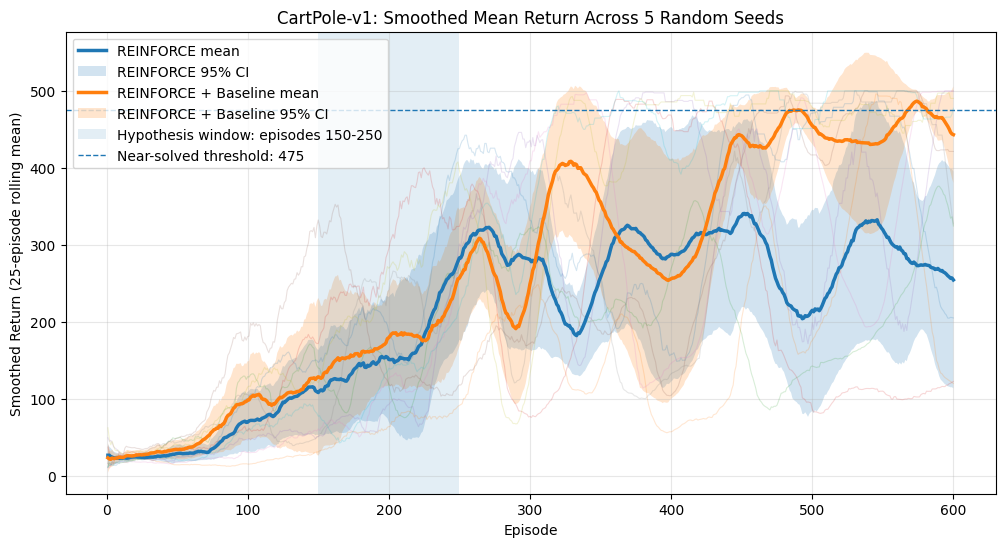

In [29]:
# TAG: plot-smoothed-mean-return-with-ci

plt.figure(figsize=(12, 6))

# Optional: show individual smoothed seed curves lightly in the background.
for (algorithm, seed), sub in results_df.groupby(["algorithm", "seed"]):
    plt.plot(
        sub["episode"],
        sub["smoothed_return"],
        linewidth=0.8,
        alpha=0.18
    )

# Main plot: mean smoothed return with 95% CI across seeds.
for algorithm in mean_return_ci["algorithm"].unique():
    sub = mean_return_ci[mean_return_ci["algorithm"] == algorithm]
    x = sub["episode"].to_numpy()
    y = sub["mean"].to_numpy()
    lower = sub["lower"].to_numpy()
    upper = sub["upper"].to_numpy()

    plt.plot(x, y, linewidth=2.5, label=f"{algorithm} mean")
    plt.fill_between(x, lower, upper, alpha=0.20, label=f"{algorithm} 95% CI")

# Hypothesis check window: baseline should begin separating around episodes 150-250.
plt.axvspan(150, 250, alpha=0.12, label="Hypothesis window: episodes 150-250")
plt.axhline(475, linestyle="--", linewidth=1, label="Near-solved threshold: 475")

plt.title(f"CartPole-v1: Smoothed Mean Return Across {len(seeds)} Random Seeds")
plt.xlabel("Episode")
plt.ylabel(f"Smoothed Return ({SMOOTHING_WINDOW}-episode rolling mean)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()


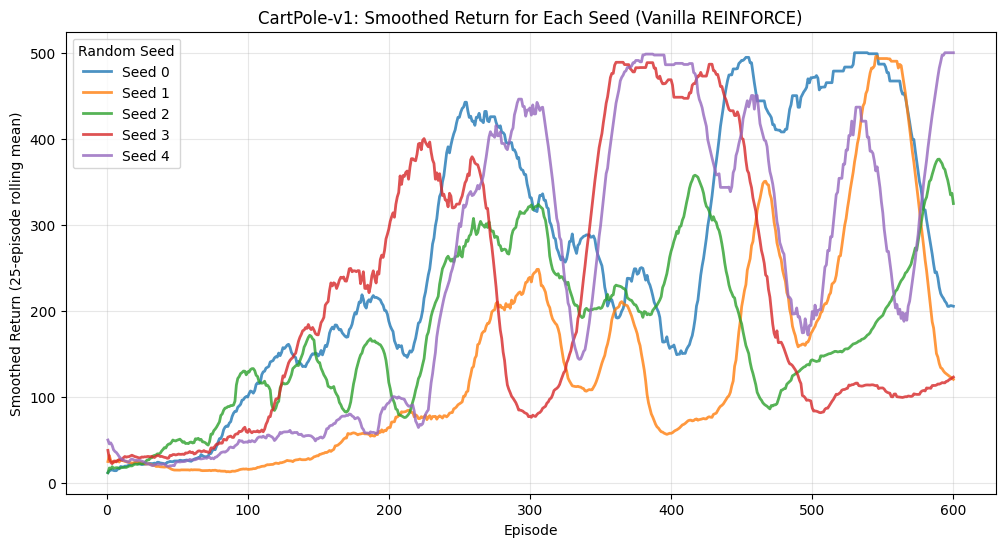

In [35]:
# Plot smoothed return for each seed of vanilla REINFORCE

plt.figure(figsize=(12, 6))

vanilla_seeds = results_df[results_df["algorithm"] == "REINFORCE"]["seed"].unique()
for seed in vanilla_seeds:
    sub = results_df[(results_df["algorithm"] == "REINFORCE") & (results_df["seed"] == seed)]
    plt.plot(
        sub["episode"],
        sub["smoothed_return"],
        label=f"Seed {seed}",
        linewidth=2.0,
        alpha=0.80
    )

plt.title("CartPole-v1: Smoothed Return for Each Seed (Vanilla REINFORCE)")
plt.xlabel("Episode")
plt.ylabel(f"Smoothed Return ({SMOOTHING_WINDOW}-episode rolling mean)")
plt.legend(title="Random Seed")
plt.grid(True, alpha=0.3)
plt.show()

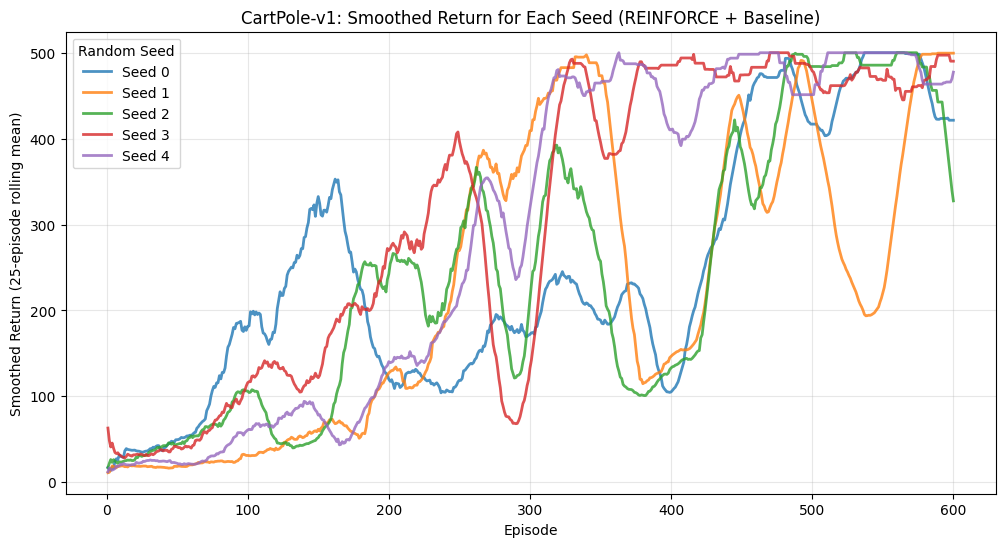

In [36]:

# Plot smoothed return for each seed of REINFORCE + Baseline

plt.figure(figsize=(12, 6))

baseline_seeds = results_df[results_df["algorithm"] == "REINFORCE + Baseline"]["seed"].unique()
for seed in baseline_seeds:
    sub = results_df[(results_df["algorithm"] == "REINFORCE + Baseline") & (results_df["seed"] == seed)]
    plt.plot(
        sub["episode"],
        sub["smoothed_return"],
        label=f"Seed {seed}",
        linewidth=2.0,
        alpha=0.80
    )

plt.title("CartPole-v1: Smoothed Return for Each Seed (REINFORCE + Baseline)")
plt.xlabel("Episode")
plt.ylabel(f"Smoothed Return ({SMOOTHING_WINDOW}-episode rolling mean)")
plt.legend(title="Random Seed")
plt.grid(True, alpha=0.3)
plt.show()



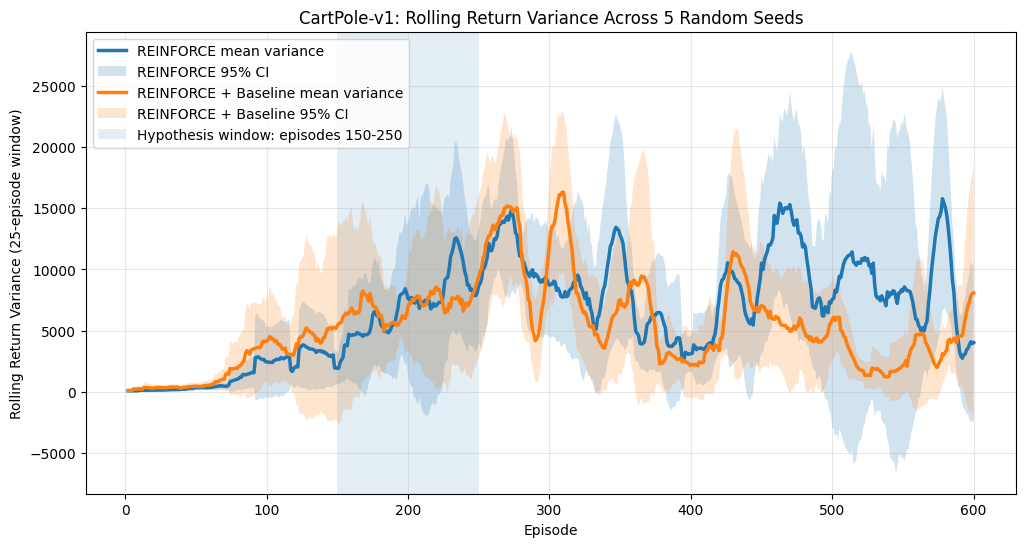

In [30]:
# TAG: plot-smoothed-return-variance-with-ci

plt.figure(figsize=(12, 6))

for algorithm in variance_ci["algorithm"].unique():
    sub = variance_ci[variance_ci["algorithm"] == algorithm]
    x = sub["episode"].to_numpy()
    y = sub["mean"].to_numpy()
    lower = sub["lower"].to_numpy()
    upper = sub["upper"].to_numpy()

    plt.plot(x, y, linewidth=2.5, label=f"{algorithm} mean variance")
    plt.fill_between(x, lower, upper, alpha=0.20, label=f"{algorithm} 95% CI")

plt.axvspan(150, 250, alpha=0.12, label="Hypothesis window: episodes 150-250")
plt.title(f"CartPole-v1: Rolling Return Variance Across {len(seeds)} Random Seeds")
plt.xlabel("Episode")
plt.ylabel(f"Rolling Return Variance ({SMOOTHING_WINDOW}-episode window)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()


## 8. Hypothesis Check Table

This table summarizes the exact windows mentioned in the hypothesis:

1. average smoothed return during episodes 150--250,
2. average confidence-interval width during episodes 150--250,
3. average smoothed return during the final 100 episodes,
4. final confidence-interval width.

A smaller CI width for the baseline method supports the claim that the baseline reduces seed-to-seed variability.


In [31]:
# TAG: hypothesis-check-table

def summarize_window(ci_df: pd.DataFrame, start_ep: int, end_ep: int, label: str) -> pd.DataFrame:
    """Summarize mean return and CI width over an episode window."""
    window_df = ci_df[(ci_df["episode"] >= start_ep) & (ci_df["episode"] <= end_ep)].copy()
    window_df["ci_width"] = window_df["upper"] - window_df["lower"]

    return (
        window_df.groupby("algorithm")
        .agg(
            mean_smoothed_return=("mean", "mean"),
            mean_ci_width=("ci_width", "mean"),
            episodes=("episode", "count")
        )
        .reset_index()
        .assign(window=label)
    )

hypothesis_window = summarize_window(mean_return_ci, 150, 250, "Episodes 150-250")
final_window = summarize_window(mean_return_ci, config.num_episodes - 99, config.num_episodes, "Final 100 episodes")

hypothesis_summary = pd.concat([hypothesis_window, final_window], ignore_index=True)

# Easier-to-read ordering
hypothesis_summary = hypothesis_summary[[
    "window", "algorithm", "mean_smoothed_return", "mean_ci_width", "episodes"
]]

display(hypothesis_summary)


,window,algorithm,mean_smoothed_return,mean_ci_width,episodes
0,Episodes 150-250,REINFORCE,166.233347,172.951314,101
1,Episodes 150-250,REINFORCE + Baseline,175.857980,154.804279,101
2,Final 100 episodes,REINFORCE,282.348400,266.935075,100
3,Final 100 episodes,REINFORCE + Baseline,450.551200,125.293228,100


## 9. Final Performance Table

This table reports the average of the last 100 episode returns for each algorithm and seed, then summarizes across seeds.


In [32]:
# TAG: final-performance-table

last_n = 100

final_by_seed = (
    results_df[results_df["episode"] > config.num_episodes - last_n]
    .groupby(["algorithm", "seed"])
    .agg(
        mean_return_last_100=("return", "mean"),
        mean_smoothed_return_last_100=("smoothed_return", "mean"),
        mean_variance_last_100=("rolling_return_variance", "mean")
    )
    .reset_index()
)

final_summary = (
    final_by_seed
    .groupby("algorithm")["mean_return_last_100"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

final_summary["sem"] = final_summary["std"] / np.sqrt(final_summary["count"])
final_summary["ci95"] = CI_Z * final_summary["sem"]
final_summary["lower"] = final_summary["mean"] - final_summary["ci95"]
final_summary["upper"] = final_summary["mean"] + final_summary["ci95"]

display(final_by_seed)
display(final_summary)


,algorithm,seed,mean_return_last_100,mean_smoothed_return_last_100,mean_variance_last_100
0,REINFORCE,0,384.48,416.5140,6668.973100
1,REINFORCE,1,316.16,325.3664,7820.941067
2,REINFORCE,2,239.12,226.2840,3289.540800
3,REINFORCE,3,111.68,105.8932,542.667567
4,REINFORCE,4,372.37,337.6844,24653.802533
5,REINFORCE + Baseline,0,472.48,465.6472,2667.597267
6,REINFORCE + Baseline,1,362.79,351.0736,4229.173667
7,REINFORCE + Baseline,2,452.48,477.2928,3856.098067
8,REINFORCE + Baseline,3,472.02,470.2840,4359.587233
9,REINFORCE + Baseline,4,490.87,488.4584,1692.693733


,algorithm,mean,std,count,sem,ci95,lower,upper
0,REINFORCE,284.762,112.522494,5,50.321589,98.630315,186.131685,383.392315
1,REINFORCE + Baseline,450.128,50.676031,5,22.663010,44.419499,405.708501,494.547499


## 10. Save Results

The training functions already save model checkpoints using `torch.save()` in:

```text
checkpoints_cartpole_reinforce/
```

This cell also saves the training results as CSV files.


In [33]:
# TAG: save-results

os.makedirs("results_cartpole_reinforce", exist_ok=True)

results_df.to_csv("results_cartpole_reinforce/training_history_all_seeds.csv", index=False)
mean_return_ci.to_csv("results_cartpole_reinforce/smoothed_mean_return_ci.csv", index=False)
variance_ci.to_csv("results_cartpole_reinforce/rolling_return_variance_ci.csv", index=False)
hypothesis_summary.to_csv("results_cartpole_reinforce/hypothesis_summary.csv", index=False)
final_by_seed.to_csv("results_cartpole_reinforce/final_by_seed.csv", index=False)
final_summary.to_csv("results_cartpole_reinforce/final_summary.csv", index=False)

print("Saved model checkpoints to:", config.checkpoint_dir)
print("Saved CSV results to: results_cartpole_reinforce/")


Saved model checkpoints to: checkpoints_cartpole_reinforce
Saved CSV results to: results_cartpole_reinforce/


## 11. Load a Saved Model Checkpoint

Use this section after training if you want to restore a saved policy and evaluate it.


In [34]:
# TAG: load-checkpoint-example

def load_policy_checkpoint(path: str) -> PolicyNetwork:
    """Load a saved policy checkpoint."""
    checkpoint = torch.load(path, map_location=DEVICE)

    temp_env = gym.make("CartPole-v1")
    obs_dim = temp_env.observation_space.shape[0]
    action_dim = temp_env.action_space.n
    temp_env.close()

    hidden_sizes = tuple(checkpoint["config"]["hidden_sizes"])

    policy = PolicyNetwork(obs_dim, action_dim, hidden_sizes).to(DEVICE)
    policy.load_state_dict(checkpoint["policy_state_dict"])
    policy.eval()
    return policy


def evaluate_policy(policy: PolicyNetwork, seed: int = 123, episodes: int = 10, render: bool = False) -> List[float]:
    """Evaluate a trained policy greedily by selecting the highest-probability action."""
    env = gym.make("CartPole-v1", render_mode="human" if render else None)
    returns = []

    for ep in range(episodes):
        obs, info = env.reset(seed=seed + ep)
        terminated = False
        truncated = False
        total_reward = 0.0

        while not (terminated or truncated):
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                logits = policy(obs_tensor)
                probs = F.softmax(logits, dim=-1)
                action = int(torch.argmax(probs, dim=-1).item())

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)

        returns.append(total_reward)

    env.close()
    return returns


# Example after running training:
# policy = load_policy_checkpoint("checkpoints_cartpole_reinforce/reinforce_baseline_seed_0.pt")
# eval_returns = evaluate_policy(policy, seed=999, episodes=10)
# print(eval_returns, np.mean(eval_returns))
